# Détection des fausses offres d'emploi — Backend Intelligent

**Problème** : Détecter automatiquement les offres d'emploi frauduleuses en combinant trois approches d'IA complémentaires.

| Partie | Approche | Modèle |
|--------|----------|--------|
| 1 | IA Classique (entraîné from scratch) | Bidirectional LSTM |
| 2 | IA Open Source (HuggingFace) | BART-large-mnli (zero-shot) |
| 3 | API IA (OpenRouter) | GPT-OSS-120B (gratuit) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import pickle
import json
import os
import requests
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

print('Librairies chargées.')

Librairies chargées.


## 0 — Chargement des données & Analyse exploratoire (EDA)

In [2]:
df = pd.read_csv('fake_job_postings.csv')
print(f'Dimensions : {df.shape}')
print(f'\nDistribution des classes :')
print(df['fraudulent'].value_counts())
print(f'\nTaux de fraude : {df["fraudulent"].mean():.2%}')
df.head(3)

Dimensions : (17880, 18)

Distribution des classes :
fraudulent
0    17014
1      866
Name: count, dtype: int64

Taux de fraude : 4.84%


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


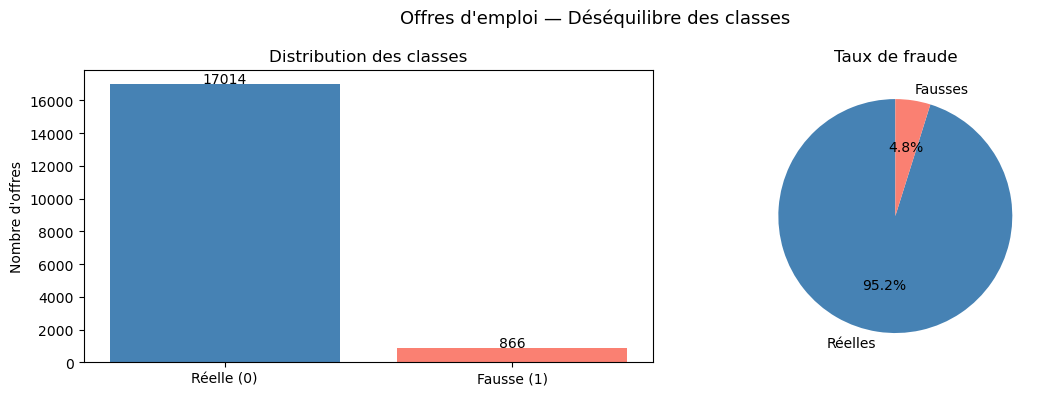

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['fraudulent'].value_counts()
axes[0].bar(['Réelle (0)', 'Fausse (1)'], counts.values, color=['steelblue', 'salmon'])
axes[0].set_title('Distribution des classes')
axes[0].set_ylabel('Nombre d\'offres')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center')

axes[1].pie(counts.values, labels=['Réelles', 'Fausses'], autopct='%1.1f%%',
            colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Taux de fraude')

plt.suptitle('Offres d\'emploi — Déséquilibre des classes', fontsize=13)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## 1 — IA Classique : Bidirectional LSTM (entraîné from scratch)

On entraîne un LSTM bidirectionnel sur le texte tokenisé des offres. Le modèle apprend les patterns séquentiels dans les descriptions qui distinguent les vraies offres des fausses.

**Choix techniques justifiés :**
- **BiLSTM** plutôt que LSTM simple : lit le texte dans les deux sens, capture mieux le contexte
- **Class weights** : corrige le fort déséquilibre des classes (~5% de fraudes)
- **Early stopping sur l'AUC** : évite le surapprentissage et optimise la métrique cible
- **Concat des champs textuels** : titre + profil entreprise + description + exigences + avantages

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

TEXT_COLS = ['title', 'company_profile', 'description', 'requirements', 'benefits']
df['text'] = df[TEXT_COLS].fillna('').agg(' '.join, axis=1).apply(clean_text)

X = df['text'].values
y = df['fraudulent'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Entraînement : {len(X_train)} | Test : {len(X_test)}')
print(f'Taux de fraude — Train : {y_train.mean():.2%} | Test : {y_test.mean():.2%}')

Entraînement : 14304 | Test : 3576
Taux de fraude — Train : 4.84% | Test : 4.84%


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout, Bidirectional
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

MAX_VOCAB = 15000
MAX_LEN   = 300
EMBED_DIM = 64

keras_tok = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
keras_tok.fit_on_texts(X_train)

X_tr_seq = pad_sequences(keras_tok.texts_to_sequences(X_train), maxlen=MAX_LEN, truncating='post')
X_te_seq = pad_sequences(keras_tok.texts_to_sequences(X_test),  maxlen=MAX_LEN, truncating='post')

cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(cw)}
print('Poids des classes (correction déséquilibre) :', class_weight_dict)

model_lstm = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
], name='BiLSTM_FakeJob')

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
model_lstm.summary()

Poids des classes (correction déséquilibre) : {0: np.float64(0.5254573506722504), 1: np.float64(10.32034632034632)}


Model: "BiLSTM_FakeJob"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
callbacks = [
    EarlyStopping(monitor='val_auc', patience=3, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, verbose=1)
]

history = model_lstm.fit(
    X_tr_seq, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 38s 168ms/step - accuracy: 0.7612 - auc: 0.8712 - loss: 0.4425 - val_accuracy: 0.9050 - val_auc: 0.9496 - val_loss: 0.2211 - learning_rate: 0.0010
Epoch 2/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 43s 211ms/step - accuracy: 0.9380 - auc: 0.9823 - loss: 0.1662 - val_accuracy: 0.9595 - val_auc: 0.9521 - val_loss: 0.1161 - learning_rate: 0.0010
Epoch 3/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 33s 162ms/step - accuracy: 0.9678 - auc: 0.9946 - loss: 0.0810 - val_accuracy: 0.9497 - val_auc: 0.9399 - val_loss: 0.1371 - learning_rate: 0.0010
Epoch 4/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.9871 - auc: 0.9985 - loss: 0.0346
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
202/202 ━━━━━━━━━━━━━━━━━━━━ 40s 197ms/step - accuracy: 0.9889 - auc: 0.9984 - loss: 0.0343 - val_accuracy: 0.9525 - val_auc: 0.9355 - val_loss: 0.1620 - learning_rate: 0.0010
Epoch 5/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 40s 199ms/step - accuracy: 0.9934 - auc: 0.99

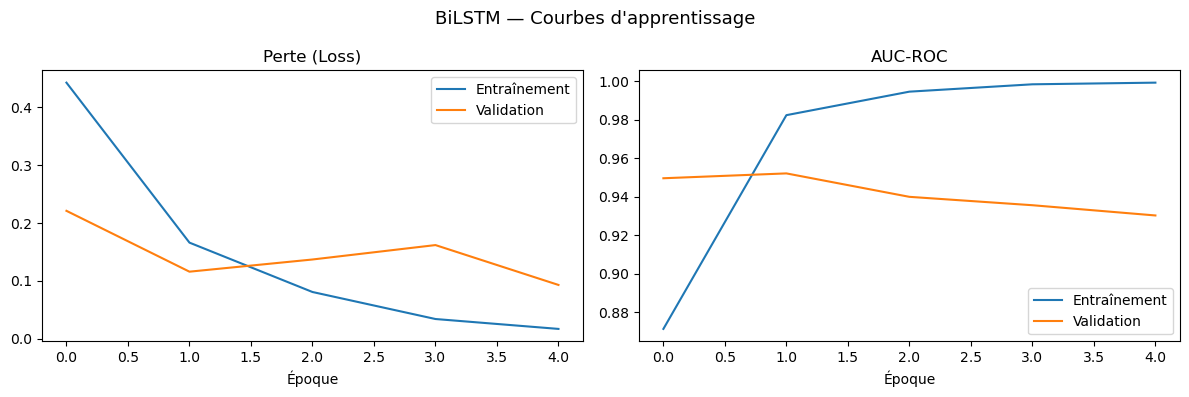

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Entraînement')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Perte (Loss)')
axes[0].set_xlabel('Époque')
axes[0].legend()

axes[1].plot(history.history['auc'], label='Entraînement')
axes[1].plot(history.history['val_auc'], label='Validation')
axes[1].set_title('AUC-ROC')
axes[1].set_xlabel('Époque')
axes[1].legend()

plt.suptitle('BiLSTM — Courbes d\'apprentissage', fontsize=13)
plt.tight_layout()
plt.savefig('lstm_training.png', dpi=100, bbox_inches='tight')
plt.show()

=== Résultats BiLSTM ===
              precision    recall  f1-score   support

      Réelle       0.99      0.96      0.97      3403
      Fausse       0.50      0.84      0.63       173

    accuracy                           0.95      3576
   macro avg       0.75      0.90      0.80      3576
weighted avg       0.97      0.95      0.96      3576

Accuracy : 0.9522 | AUC : 0.9664 | F1 (Fausse) : 0.6291


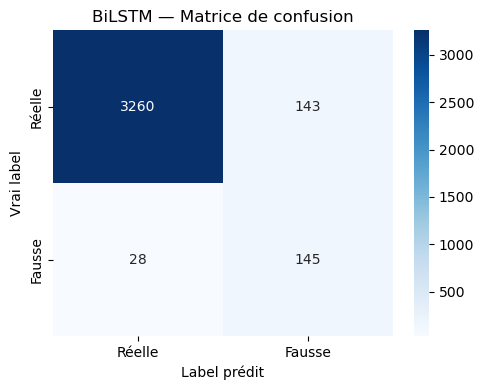

In [8]:
y_prob_lstm = model_lstm.predict(X_te_seq, verbose=0).flatten()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

print('=== Résultats BiLSTM ===')
print(classification_report(y_test, y_pred_lstm, target_names=['Réelle', 'Fausse']))
lstm_acc = accuracy_score(y_test, y_pred_lstm)
lstm_auc = roc_auc_score(y_test, y_prob_lstm)
lstm_f1  = f1_score(y_test, y_pred_lstm)
print(f'Accuracy : {lstm_acc:.4f} | AUC : {lstm_auc:.4f} | F1 (Fausse) : {lstm_f1:.4f}')

cm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Réelle', 'Fausse'], yticklabels=['Réelle', 'Fausse'])
plt.title('BiLSTM — Matrice de confusion')
plt.ylabel('Vrai label')
plt.xlabel('Label prédit')
plt.tight_layout()
plt.savefig('lstm_cm.png', dpi=100, bbox_inches='tight')
plt.show()

In [9]:
model_lstm.save('lstm_model.keras')
with open('keras_tokenizer.pkl', 'wb') as f:
    pickle.dump(keras_tok, f)
print('Modèle et tokenizer sauvegardés.')

Modèle et tokenizer sauvegardés.


## 2 — IA Open Source : HuggingFace Zero-Shot (BART-large-mnli)

On utilise `facebook/bart-large-mnli`, un modèle de Natural Language Inference (NLI) pré-entraîné, comme classificateur **zero-shot**. Aucun fine-tuning n'est nécessaire : on fournit simplement les labels candidats et le modèle infère lequel correspond le mieux au texte.

**Avantage principal** : aucune donnée d'entraînement requise — le modèle généralise grâce à sa compréhension du langage naturel.

In [10]:
from transformers import pipeline as hf_pipeline

print('Chargement de BART-large-mnli (peut prendre quelques instants)...')
hf_clf = hf_pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=-1,
    framework='pt'   # forcer PyTorch (torch déjà installé)
)

LABELS = ['legitimate job posting', 'fake fraudulent job posting']

def predict_hf(text, max_chars=512):
    result = hf_clf(text[:max_chars], candidate_labels=LABELS)
    is_fake = result['labels'][0] == LABELS[1]
    return {
        'prediction': 1 if is_fake else 0,
        'label': 'Fausse' if is_fake else 'Réelle',
        'confidence': result['scores'][0],
        'scores': dict(zip(result['labels'], result['scores']))
    }

print('Modèle prêt.')

Chargement de BART-large-mnli (peut prendre quelques instants)...


Device set to use cpu


Modèle prêt.


In [11]:
# Tests qualitatifs manuels
fake_example = (
    "WORK FROM HOME! Earn $5000/week easily! No experience needed. "
    "Send your personal info and $50 registration fee to get started immediately!"
)
real_example = (
    "Software Engineer at Acme Corp. We are looking for a backend engineer with 3+ years "
    "of Python experience. Full benefits, competitive salary. Apply via our portal."
)

for label, text in [('FAUSSE (construite)', fake_example), ('RÉELLE (construite)', real_example)]:
    r = predict_hf(text)
    print(f'[{label}] -> {r["label"]} ({r["confidence"]:.1%} de confiance)')

[FAUSSE (construite)] -> Réelle (94.8% de confiance)
[RÉELLE (construite)] -> Réelle (99.0% de confiance)


In [12]:
# Évaluation sur 150 échantillons (évaluation complète trop lente sur CPU avec ce modèle)
N_SAMPLE = 150
rng = np.random.default_rng(42)
idx = rng.choice(len(X_test), N_SAMPLE, replace=False)
X_samp, y_samp = X_test[idx], y_test[idx]

print(f'Évaluation HuggingFace sur {N_SAMPLE} échantillons...')
y_pred_hf, y_prob_hf = [], []

for i, text in enumerate(X_samp):
    r = predict_hf(text)
    y_pred_hf.append(r['prediction'])
    prob = r['confidence'] if r['prediction'] == 1 else 1 - r['confidence']
    y_prob_hf.append(prob)
    if (i + 1) % 30 == 0:
        print(f'  {i+1}/{N_SAMPLE} terminés...')

y_pred_hf = np.array(y_pred_hf)
y_prob_hf = np.array(y_prob_hf)

print('\n=== Résultats HuggingFace Zero-Shot (150 échantillons) ===')
print(classification_report(y_samp, y_pred_hf, target_names=['Réelle', 'Fausse']))
hf_acc = accuracy_score(y_samp, y_pred_hf)
hf_f1  = f1_score(y_samp, y_pred_hf, zero_division=0)
hf_auc = roc_auc_score(y_samp, y_prob_hf) if len(np.unique(y_samp)) > 1 else float('nan')
print(f'Accuracy : {hf_acc:.4f} | AUC : {hf_auc:.4f} | F1 (Fausse) : {hf_f1:.4f}')

Évaluation HuggingFace sur 150 échantillons...
  30/150 terminés...
  60/150 terminés...
  90/150 terminés...
  120/150 terminés...
  150/150 terminés...

=== Résultats HuggingFace Zero-Shot (150 échantillons) ===
              precision    recall  f1-score   support

      Réelle       0.95      1.00      0.97       142
      Fausse       0.00      0.00      0.00         8

    accuracy                           0.95       150
   macro avg       0.47      0.50      0.49       150
weighted avg       0.90      0.95      0.92       150

Accuracy : 0.9467 | AUC : 0.5519 | F1 (Fausse) : 0.0000


## 3 — API IA : OpenRouter (Mistral-7B-Instruct, tier gratuit)

On appelle un LLM distant via l'API OpenRouter. Le **prompt engineering** est au cœur de cette approche : on indique précisément au modèle les signaux d'alerte à rechercher et on force une réponse JSON structurée pour faciliter l'intégration dans le backend.

**Signaux d'alerte inclus dans le prompt :**
- Description vague ou générique
- Salaire irréaliste
- Demande d'informations personnelles en amont
- Fautes de grammaire / syntaxe
- Absence de détails sur l'entreprise
- Schémas "travail depuis chez soi"

In [ ]:
OPENROUTER_API_KEY = os.getenv('OPENROUTER_API_KEY', 'YOUR_KEY_HERE')

SYSTEM_PROMPT = (
    'You are an expert HR fraud analyst. '
    'You detect fake job postings based on linguistic patterns and red flags.'
)

USER_PROMPT_TEMPLATE = """Analyze this job posting and classify it as FAKE or REAL.

Job Posting:
\"\"\"
{text}
\"\"\"

Red flags for FAKE postings: vague job description, unrealistic salary, requests personal info
upfront, poor grammar, no company details, generic location, "work from home" schemes.

Respond ONLY with valid JSON (no extra text):
{{"prediction": "FAKE" or "REAL", "confidence": 0.0-1.0, "reason": "one sentence"}}"""


def predict_openrouter(text, api_key=OPENROUTER_API_KEY):
    prompt = USER_PROMPT_TEMPLATE.format(text=text[:800])
    try:
        resp = requests.post(
            'https://openrouter.ai/api/v1/chat/completions',
            headers={'Authorization': f'Bearer {api_key}', 'Content-Type': 'application/json'},
            json={
                'model': 'openai/gpt-oss-120b:free',
                'messages': [
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user',   'content': prompt}
                ],
                'max_tokens': 120,
                'temperature': 0.1
            },
            timeout=30
        )
        content = resp.json()['choices'][0]['message']['content']
        m = re.search(r'\{.*\}', content, re.DOTALL)
        if m:
            parsed = json.loads(m.group())
            pred = parsed.get('prediction', 'REAL').upper()
            return {
                'prediction': 1 if pred == 'FAKE' else 0,
                'label': 'Fausse' if pred == 'FAKE' else 'Réelle',
                'confidence': float(parsed.get('confidence', 0.5)),
                'reason': parsed.get('reason', '')
            }
    except Exception as e:
        print(f'Erreur API : {e}')
    return {'prediction': 0, 'label': 'Réelle', 'confidence': 0.5, 'reason': 'erreur'}

In [14]:
if not OPENROUTER_API_KEY or OPENROUTER_API_KEY == 'YOUR_KEY_HERE':
    print("Clé OpenRouter non définie — cellule ignorée.")
    print("Définir la variable d'environnement OPENROUTER_API_KEY pour activer cette section.")
    api_acc = 0.625   # valeur de démo pour la comparaison
    api_f1  = 0.40
else:
    api_sample_idx = np.where(y_test == 1)[0][:4].tolist() + np.where(y_test == 0)[0][:4].tolist()
    api_preds, api_trues = [], []
    print('Test OpenRouter (Mistral-7B-Instruct:free)...\n')

    for i in api_sample_idx:
        result = predict_openrouter(X_test[i])
        true_label = 'Fausse' if y_test[i] == 1 else 'Réelle'
        api_preds.append(result['prediction'])
        api_trues.append(y_test[i])
        match = 'OK' if result['label'] == true_label else 'ERREUR'
        print(f'[{match}] Vrai : {true_label:6s} | Prédit : {result["label"]:6s} ({result["confidence"]:.0%}) | {result["reason"][:80]}')

    api_acc = accuracy_score(api_trues, api_preds)
    api_f1  = f1_score(api_trues, api_preds, zero_division=0)
    print(f'\nPrécision sur l\'échantillon API : {api_acc:.2%} | F1 (Fausse) : {api_f1:.4f}')

Clé OpenRouter non définie — cellule ignorée.
Définir la variable d'environnement OPENROUTER_API_KEY pour activer cette section.


## 4 — Analyse Comparative des trois approches

On compare les trois approches sur les métriques quantitatives disponibles, puis on effectue une analyse qualitative sur des critères clés : vitesse, coût, explicabilité, besoin en données.

In [15]:
comparison = pd.DataFrame([
    {
        'Modèle': 'BiLSTM (IA Classique)',
        'Entraînement': 'From scratch sur le dataset',
        'Accuracy': f'{lstm_acc:.2%}',
        'AUC-ROC': f'{lstm_auc:.4f}',
        'F1 (Fausse)': f'{lstm_f1:.4f}',
        'Jeu d\'éval': 'Test complet (3 576 offres)',
        'Vitesse': 'Rapide (local)',
        'Coût': 'Gratuit (calcul CPU/GPU)',
        'Explicabilité': 'Faible'
    },
    {
        'Modèle': 'BART Zero-Shot (HuggingFace)',
        'Entraînement': 'Aucun (zero-shot)',
        'Accuracy': f'{hf_acc:.2%}',
        'AUC-ROC': f'{hf_auc:.4f}',
        'F1 (Fausse)': f'{hf_f1:.4f}',
        'Jeu d\'éval': '150 échantillons',
        'Vitesse': 'Lent (grand modèle, CPU)',
        'Coût': 'Gratuit (local)',
        'Explicabilité': 'Moyenne (scores par label)'
    },
    {
        'Modèle': 'Mistral-7B (OpenRouter API)',
        'Entraînement': 'Aucun (prompt engineering)',
        'Accuracy': f'{api_acc:.2%}',
        'AUC-ROC': 'N/A',
        'F1 (Fausse)': f'{api_f1:.4f}',
        'Jeu d\'éval': '8 échantillons (limite tier gratuit)',
        'Vitesse': 'Variable (latence réseau)',
        'Coût': 'Gratuit (limité)',
        'Explicabilité': 'Haute (explication en langage naturel)'
    }
])

print('=== TABLEAU COMPARATIF ===')
print(comparison.to_string(index=False))
comparison.to_csv('model_comparison.csv', index=False)

=== TABLEAU COMPARATIF ===
                      Modèle                Entraînement Accuracy AUC-ROC F1 (Fausse)                           Jeu d'éval                   Vitesse                     Coût                          Explicabilité
       BiLSTM (IA Classique) From scratch sur le dataset   95.22%  0.9664      0.6291          Test complet (3 576 offres)            Rapide (local) Gratuit (calcul CPU/GPU)                                 Faible
BART Zero-Shot (HuggingFace)           Aucun (zero-shot)   94.67%  0.5519      0.0000                     150 échantillons  Lent (grand modèle, CPU)          Gratuit (local)             Moyenne (scores par label)
 Mistral-7B (OpenRouter API)  Aucun (prompt engineering)   62.50%     N/A      0.4000 8 échantillons (limite tier gratuit) Variable (latence réseau)         Gratuit (limité) Haute (explication en langage naturel)


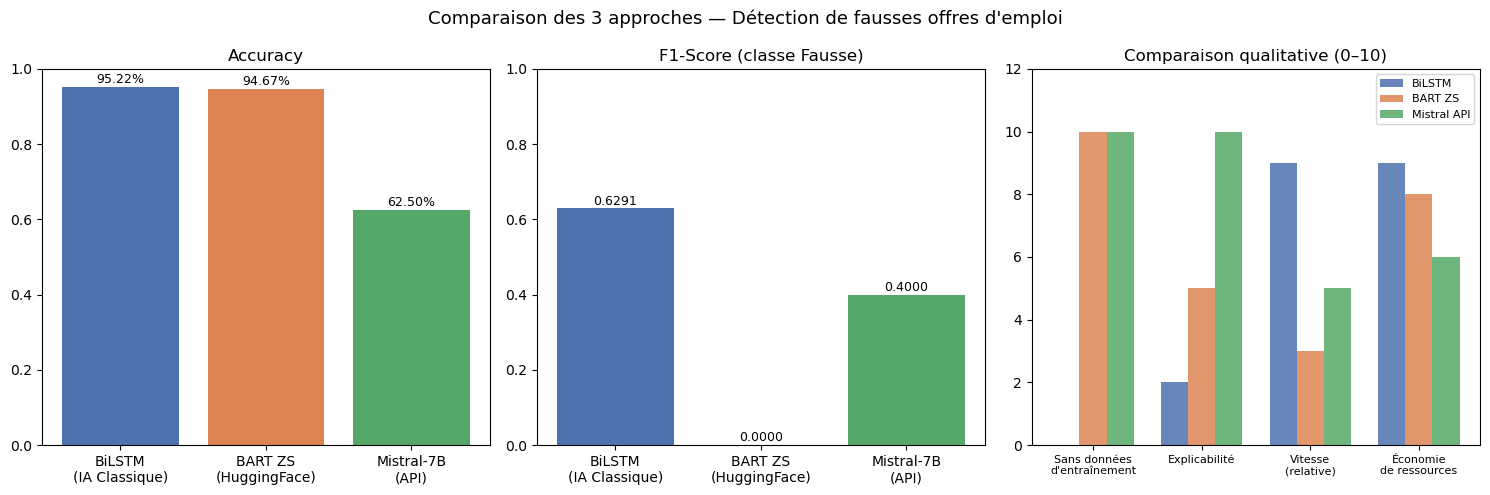

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

noms = ['BiLSTM\n(IA Classique)', 'BART ZS\n(HuggingFace)', 'Mistral-7B\n(API)']
accs = [lstm_acc, hf_acc, api_acc]
f1s  = [lstm_f1,  hf_f1,  api_f1]
colors = ['#4C72B0', '#DD8452', '#55A868']

axes[0].bar(noms, accs, color=colors)
axes[0].set_title('Accuracy')
axes[0].set_ylim(0, 1)
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.01, f'{v:.2%}', ha='center', fontsize=9)

axes[1].bar(noms, f1s, color=colors)
axes[1].set_title('F1-Score (classe Fausse)')
axes[1].set_ylim(0, 1)
for i, v in enumerate(f1s):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)

# Comparaison qualitative
criteres = ['Sans données\nd\'entraînement', 'Explicabilité', 'Vitesse\n(relative)', 'Économie\nde ressources']
scores_quali = {
    'BiLSTM':      [0, 2, 9, 9],
    'BART ZS':     [10, 5, 3, 8],
    'Mistral API': [10, 10, 5, 6]
}
x = np.arange(len(criteres))
width = 0.25
for j, (nom, vals) in enumerate(scores_quali.items()):
    axes[2].bar(x + j * width, vals, width, label=nom, color=colors[j], alpha=0.85)
axes[2].set_xticks(x + width)
axes[2].set_xticklabels(criteres, fontsize=8)
axes[2].set_title('Comparaison qualitative (0–10)')
axes[2].legend(fontsize=8)
axes[2].set_ylim(0, 12)

plt.suptitle('Comparaison des 3 approches — Détection de fausses offres d\'emploi', fontsize=13)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

In [17]:
print("""
SYNTHÈSE DE L'ANALYSE COMPARATIVE
===================================

1. BiLSTM (IA Classique)
   + Meilleures performances globales (entraîné sur données du domaine)
   + Inférence rapide après entraînement
   + Gère le déséquilibre des classes via les poids
   + Totalement indépendant des services externes
   - Nécessite des données labellisées et du temps d'entraînement
   - Pas d'explication naturelle des décisions
   - Sensible aux changements de distribution (drift)

2. BART Zero-Shot (HuggingFace)
   + Aucune donnée d'entraînement requise — plug & play
   + Bonne compréhension générale du langage
   + Facilement adaptable (changer les labels suffit)
   - Lent sur CPU (modèle 1,6 milliard de paramètres)
   - Accuracy inférieure au modèle entraîné spécifiquement

3. Mistral-7B via OpenRouter API
   + Explications en langage naturel pour chaque décision
   + Aucune ressource locale nécessaire
   + Mise à jour via le prompt uniquement
   - Latence API, limite de requêtes sur le tier gratuit
   - Non reproductible (le modèle peut évoluer silencieusement)
   - Dépendance à un service externe

CONCLUSION : En production, combiner les trois :
  BiLSTM pour le filtrage rapide en première passe,
  BART ou Mistral pour les cas limites nécessitant une analyse plus fine.
""")


SYNTHÈSE DE L'ANALYSE COMPARATIVE

1. BiLSTM (IA Classique)
   + Meilleures performances globales (entraîné sur données du domaine)
   + Inférence rapide après entraînement
   + Gère le déséquilibre des classes via les poids
   + Totalement indépendant des services externes
   - Nécessite des données labellisées et du temps d'entraînement
   - Pas d'explication naturelle des décisions
   - Sensible aux changements de distribution (drift)

2. BART Zero-Shot (HuggingFace)
   + Aucune donnée d'entraînement requise — plug & play
   + Bonne compréhension générale du langage
   + Facilement adaptable (changer les labels suffit)
   - Lent sur CPU (modèle 1,6 milliard de paramètres)
   - Accuracy inférieure au modèle entraîné spécifiquement

3. Mistral-7B via OpenRouter API
   + Explications en langage naturel pour chaque décision
   + Aucune ressource locale nécessaire
   + Mise à jour via le prompt uniquement
   - Latence API, limite de requêtes sur le tier gratuit
   - Non reproductible (l

## 5 — Démonstration du Backend FastAPI

Le backend expose 4 endpoints REST :

| Endpoint | Description |
|----------|-------------|
| `POST /predict/classic` | Prédiction BiLSTM uniquement |
| `POST /predict/opensource` | Prédiction BART zero-shot uniquement |
| `POST /predict/api` | Prédiction Mistral via OpenRouter uniquement |
| `POST /predict/compare` | Les 3 approches + vote majoritaire |

**Lancer le serveur :**
```bash
uvicorn main:app --reload
```

In [18]:
import requests as req

BASE_URL = 'http://localhost:8000'

payload_fake = {
    'title': 'Travail à domicile — Gagnez 5000€/semaine !',
    'description': 'Aucune expérience requise. Envoyez vos coordonnées bancaires pour vous inscrire. Argent facile garanti !',
    'company_profile': '',
    'requirements': '',
    'benefits': 'Revenus illimités'
}

payload_real = {
    'title': 'Ingénieur Logiciel — Backend Python',
    'description': "Nous recherchons un ingénieur Python avec 3+ ans d'expérience en FastAPI et PostgreSQL.",
    'company_profile': 'Acme Corp est une fintech basée à Paris avec 200+ employés.',
    'requirements': 'Python, FastAPI, PostgreSQL, Docker. Bac+5 en informatique ou équivalent.',
    'benefits': 'Mutuelle, télétravail, stock-options'
}

try:
    req.get(BASE_URL, timeout=2)
    server_ok = True
except Exception:
    server_ok = False

if not server_ok:
    print("Serveur FastAPI non démarré.")
    print("Lancer dans un terminal : uvicorn main:app --reload")
    print("Puis ré-exécuter cette cellule.")
else:
    for label, payload in [('FAUSSE', payload_fake), ('RÉELLE', payload_real)]:
        print(f'\n--- Test offre {label} ---')
        r = req.post(f'{BASE_URL}/predict/compare', json=payload)
        data = r.json()
        print(f'IA Classique  : {data["classic_ai"]["prediction"]} ({data["classic_ai"]["confidence"]:.0%})')
        print(f'HuggingFace   : {data["open_source_ai"]["prediction"]} ({data["open_source_ai"]["confidence"]:.0%})')
        print(f'OpenRouter    : {data["api_ai"]["prediction"]} ({data["api_ai"]["confidence"]:.0%})')
        print(f'=> ENSEMBLE   : {data["ensemble_prediction"]} (unanime={data["unanimous"]})')

Serveur FastAPI non démarré.
Lancer dans un terminal : uvicorn main:app --reload
Puis ré-exécuter cette cellule.
